# Task 02 – Customer Personality Segmentation

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load and Explore Dataset

In [3]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## 3. Dataset Information


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

## 4. Data Cleaning

In [5]:
df["Income"] = df["Income"].fillna(df["Income"].median())

df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [6]:
df["Income"] = df["Income"].fillna(df["Income"].median())

## 5. Feature Engineering

In [7]:
df["Age"] = 2025 - df["Year_Birth"]

df["Total_Spending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

df[["Age", "Total_Spending"]].head()

,Age,Total_Spending
0,68,1617
1,71,27
2,60,776
3,41,53
4,44,422


In [8]:
print("Total_Spending" in df.columns)

True


## 6. Customer Segmentation using K-Means Clustering

In [14]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = df[["Income", "Total_Spending"]]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans.fit_predict(scaled_features)

df["Cluster"].value_counts()

Cluster
2    1133
0     652
1     455
Name: count, dtype: int64

In [15]:
cluster_spending = df.groupby("Cluster")["Total_Spending"].mean().sort_values()

mapping = {
    cluster_spending.index[0]: "Low",
    cluster_spending.index[1]: "Medium",
    cluster_spending.index[2]: "High"
}

df["Segment"] = df["Cluster"].map(mapping)

df["Segment"].value_counts()

Segment
Low       1133
Medium     652
High       455
Name: count, dtype: int64

## 7. Visualize Customer Segments

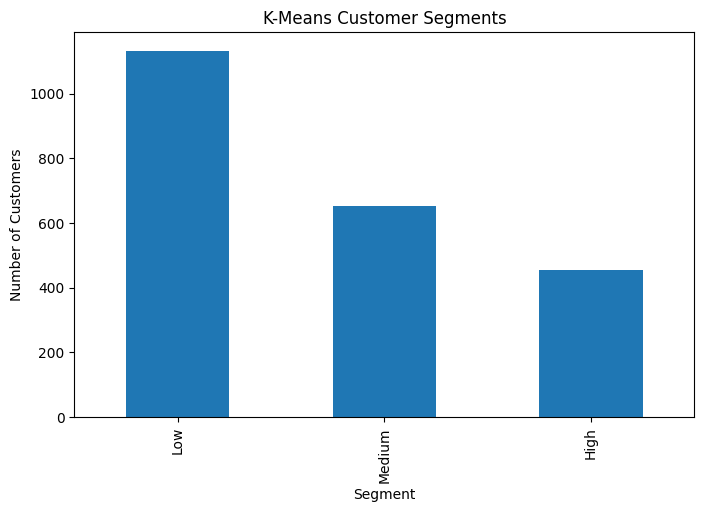

In [13]:
import matplotlib.pyplot as plt

df["Segment"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("K-Means Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

## 8. Segment Analysis

In [ ]:
segment_summary = df.groupby("Segment")[["Income", "Age", "Total_Spending"]].mean()

segment_summary

,Income,Age,Total_Spending
Segment,,,
Low,35922.384615,54.062317,90.743914
Medium,57696.749591,58.603928,632.103110
High,74531.664452,57.385382,1457.772425


## 9. Segment Analysis Dashboard

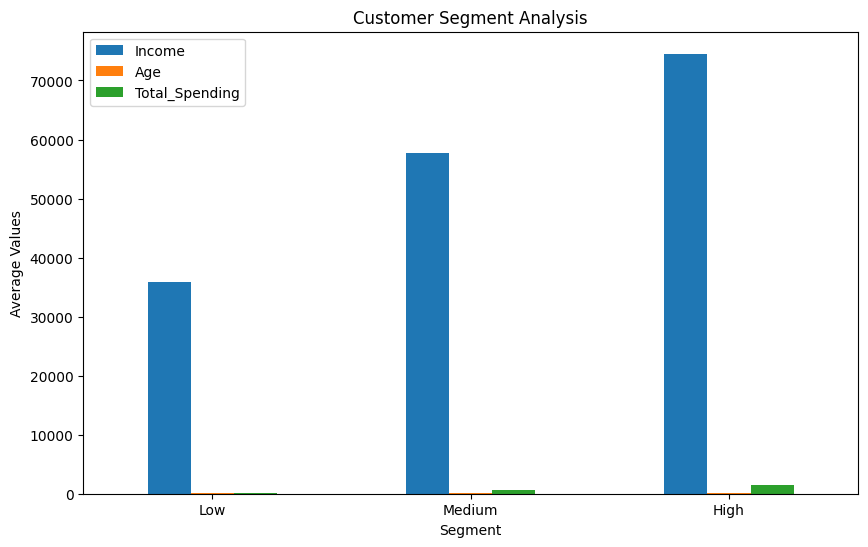

In [ ]:
import matplotlib.pyplot as plt

segment_summary.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Customer Segment Analysis")
plt.ylabel("Average Values")
plt.xticks(rotation=0)
plt.show()

## 10. Conclusion

### Key Insights

- Customer segmentation was successfully performed using the K-Means Clustering Algorithm.
- The dataset was divided into three distinct customer clusters.
- Customers were categorized into Low, Medium, and High value segments based on spending behavior.
- High-value customers showed the highest average income and total spending.
- Medium-value customers exhibited balanced purchasing and spending patterns.
- Low-value customers contributed the least to overall spending activity.
- Cluster analysis revealed clear differences in customer purchasing behavior.
- Businesses can use these customer segments for targeted marketing strategies.
- Personalized offers and recommendations can be designed for each segment.
- K-Means clustering helps improve customer understanding and supports data-driven business decisions.